In [35]:
import pandas as pd
import numpy as np
import joblib
import random

In [36]:
model = joblib.load(
    '../models/xgb_wc_predictor.pkl'
)

scaler = joblib.load(
    '../models/scaler.pkl'
)

In [37]:
fixtures = pd.read_csv(
    '../data/raw/wc2026_fixtures.csv'
)

fixtures.head()

,date,match_number,teams,group,stadium,date_dt
0,"Thursday, 11 June 2026",Match 1,Mexico v South Africa,Group A,Mexico City Stadium,2026-06-11
1,"Thursday, 11 June 2026",Match 2,Korea Republic v Czechia/Denmark/North Macedon...,Group A,Estadio Guadalajara,2026-06-11
2,"Friday, 12 June 2026",Match 3,Canada v Bosnia and Herzegovina/Italy/Northern...,Group B,Toronto Stadium,2026-06-12
3,"Friday, 12 June 2026",Match 4,USA v Paraguay,Group D,Los Angeles Stadium,2026-06-12
4,"Saturday, 13 June 2026",Match 5,Haiti v Scotland,Group C,Boston Stadium,2026-06-13


In [38]:
elo = pd.read_csv(
    '../data/raw/elo_ratings.csv'
)

In [39]:
elo = pd.read_csv(
    '../data/raw/elo_ratings.csv'
)

In [40]:
elo['snapshot_date'] = pd.to_datetime(
    elo['snapshot_date']
)

latest_elo = (
    elo.sort_values('snapshot_date')
       .groupby('country')
       .tail(1)
)

In [41]:
elo_dict = dict(
    zip(
        latest_elo['country'],
        latest_elo['rating']
    )
)

In [42]:
def create_match_features(
    home_team,
    away_team
):
    
    home_elo = elo_dict.get(home_team, 1500)
    away_elo = elo_dict.get(away_team, 1500)
    
    elo_diff = home_elo - away_elo
    
    features = pd.DataFrame({
        'home_elo': [home_elo],
        'away_elo': [away_elo],
        'elo_diff': [elo_diff],
        
        'home_rank': [50],
        'away_rank': [50],
        'rank_diff': [0],
        
        'neutral': [1],
        'is_competitive': [1],
        
        'home_form': [1.5],
        'away_form': [1.5],
        'form_diff': [0],
        
        'home_attack_strength': [1.5],
        'away_attack_strength': [1.5],
        
        'home_defense_strength': [1.0],
        'away_defense_strength': [1.0]
    })
    
    return features

In [43]:
def predict_match(
    home_team,
    away_team
):
    
    features = create_match_features(
        home_team,
        away_team
    )
    
    prediction = model.predict(features)[0]
    
    probabilities = model.predict_proba(features)[0]
    
    return prediction, probabilities

In [44]:
prediction, probs = predict_match(
    'France',
    'Argentina'
)

print("Prediction:", prediction)
print("Probabilities:", probs)

Prediction: 1
Probabilities: [0.35982877 0.49942738 0.14074394]


In [45]:
result_map = {
    0: 'Away Win',
    1: 'Draw',
    2: 'Home Win'
}

In [46]:
print(result_map[prediction])

Draw


In [47]:
def simulate_match(
    home_team,
    away_team
):
    
    _, probs = predict_match(
        home_team,
        away_team
    )
    
    outcome = np.random.choice(
        [0,1,2],
        p=probs
    )
    
    return outcome

In [48]:
fixtures.columns

Index(['date', 'match_number', 'teams', 'group', 'stadium', 'date_dt'], dtype='object')

In [49]:
fixtures.head()

,date,match_number,teams,group,stadium,date_dt
0,"Thursday, 11 June 2026",Match 1,Mexico v South Africa,Group A,Mexico City Stadium,2026-06-11
1,"Thursday, 11 June 2026",Match 2,Korea Republic v Czechia/Denmark/North Macedon...,Group A,Estadio Guadalajara,2026-06-11
2,"Friday, 12 June 2026",Match 3,Canada v Bosnia and Herzegovina/Italy/Northern...,Group B,Toronto Stadium,2026-06-12
3,"Friday, 12 June 2026",Match 4,USA v Paraguay,Group D,Los Angeles Stadium,2026-06-12
4,"Saturday, 13 June 2026",Match 5,Haiti v Scotland,Group C,Boston Stadium,2026-06-13


In [50]:
fixtures['teams'].head(20)

0                                 Mexico v South Africa
1     Korea Republic v Czechia/Denmark/North Macedon...
2     Canada v Bosnia and Herzegovina/Italy/Northern...
3                                        USA v Paraguay
4                                      Haiti v Scotland
5           Australia v Kosovo/Romania/Slovakia/Türkiye
6                                      Brazil v Morocco
7                                   Qatar v Switzerland
8                               Côte d'Ivoire v Ecuador
9                                     Germany v Curaçao
10                                  Netherlands v Japan
11              Albania/Poland/Sweden/Ukraine v Tunisia
12                               Saudi Arabia v Uruguay
13                                   Spain v Cabo Verde
14                                IR Iran v New Zealand
15                                      Belgium v Egypt
16                                     France v Senegal
17                       Bolivia/Iraq/Suriname v

In [51]:
fixtures[['home_team', 'away_team']] = (
    fixtures['teams']
    .str.split(' v ', expand=True)
)

In [52]:
fixtures['home_team'] = (
    fixtures['home_team'].str.strip()
)

fixtures['away_team'] = (
    fixtures['away_team'].str.strip()
)

In [66]:
fixtures['home_team'] = fixtures['home_team'].replace(
    'Albania/Poland/Sweden/Ukraine',
    'Sweden'
)

fixtures['away_team'] = fixtures['away_team'].replace(
    'Kosovo/Romania/Slovakia/Türkiye',
    'Türkiye'
)

In [67]:
teams = pd.unique(
    fixtures[['home_team', 'away_team']]
    .values.ravel()
)

In [68]:
fixtures[['home_team', 'away_team']].head()

,home_team,away_team
0,Mexico,South Africa
1,Korea Republic,Czechia/Denmark/North Macedonia/Republic of Ir...
2,Canada,Bosnia and Herzegovina/Italy/Northern Ireland/...
3,USA,Paraguay
4,Haiti,Scotland


In [69]:
teams = pd.unique(
    fixtures[['home_team', 'away_team']]
    .values.ravel()
)

standings = pd.DataFrame({
    'team': teams,
    'points': 0,
    'gf': 0,
    'ga': 0
})

In [70]:
for _, row in fixtures.iterrows():
    
    home = row['home_team']
    away = row['away_team']
    
    result = simulate_match(
        home,
        away
    )
    
    if result == 2:
        
        standings.loc[
            standings['team'] == home,
            'points'
        ] += 3
        
    elif result == 0:
        
        standings.loc[
            standings['team'] == away,
            'points'
        ] += 3
        
    else:
        
        standings.loc[
            standings['team'] == home,
            'points'
        ] += 1
        
        standings.loc[
            standings['team'] == away,
            'points'
        ] += 1

In [71]:
standings = standings.sort_values(
    by='points',
    ascending=False
)

standings.head(20)

,team,points,gf,ga
14,Qatar,9,0,0
21,Japan,7,0,0
2,Korea Republic,7,0,0
41,Panama,7,0,0
16,Côte d'Ivoire,7,0,0
31,Egypt,7,0,0
3,Czechia/Denmark/North Macedonia/Republic of Ir...,6,0,0
40,Ghana,6,0,0
18,Germany,6,0,0
30,Belgium,6,0,0


In [72]:
winner = standings.iloc[0]['team']

print("Predicted Champion:", winner)

Predicted Champion: Qatar


In [73]:
simulation_results = []

In [74]:
simulation_results = []

for sim in range(100):

    print(f"Running Simulation {sim+1}")

    standings = pd.DataFrame({
        'team': teams,
        'points': 0
    })

    for _, row in fixtures.iterrows():

        home = row['home_team']
        away = row['away_team']

        result = simulate_match(
            home,
            away
        )

        if result == 2:

            standings.loc[
                standings['team'] == home,
                'points'
            ] += 3

        elif result == 0:

            standings.loc[
                standings['team'] == away,
                'points'
            ] += 3

        else:

            standings.loc[
                standings['team'] == home,
                'points'
            ] += 1

            standings.loc[
                standings['team'] == away,
                'points'
            ] += 1

    standings = standings.sort_values(
        by='points',
        ascending=False
    )

    champion = standings.iloc[0]['team']

    simulation_results.append(champion)

Running Simulation 1
Running Simulation 2
Running Simulation 3
Running Simulation 4
Running Simulation 5
Running Simulation 6
Running Simulation 7
Running Simulation 8
Running Simulation 9
Running Simulation 10
Running Simulation 11
Running Simulation 12
Running Simulation 13
Running Simulation 14
Running Simulation 15
Running Simulation 16
Running Simulation 17
Running Simulation 18
Running Simulation 19
Running Simulation 20
Running Simulation 21
Running Simulation 22
Running Simulation 23
Running Simulation 24
Running Simulation 25
Running Simulation 26
Running Simulation 27
Running Simulation 28
Running Simulation 29
Running Simulation 30
Running Simulation 31
Running Simulation 32
Running Simulation 33
Running Simulation 34
Running Simulation 35
Running Simulation 36
Running Simulation 37
Running Simulation 38
Running Simulation 39
Running Simulation 40
Running Simulation 41
Running Simulation 42
Running Simulation 43
Running Simulation 44
Running Simulation 45
Running Simulation 

In [75]:
champion_counts = pd.Series(
    simulation_results
).value_counts()

In [76]:
champion_probs = (
    champion_counts / len(simulation_results)
) * 100

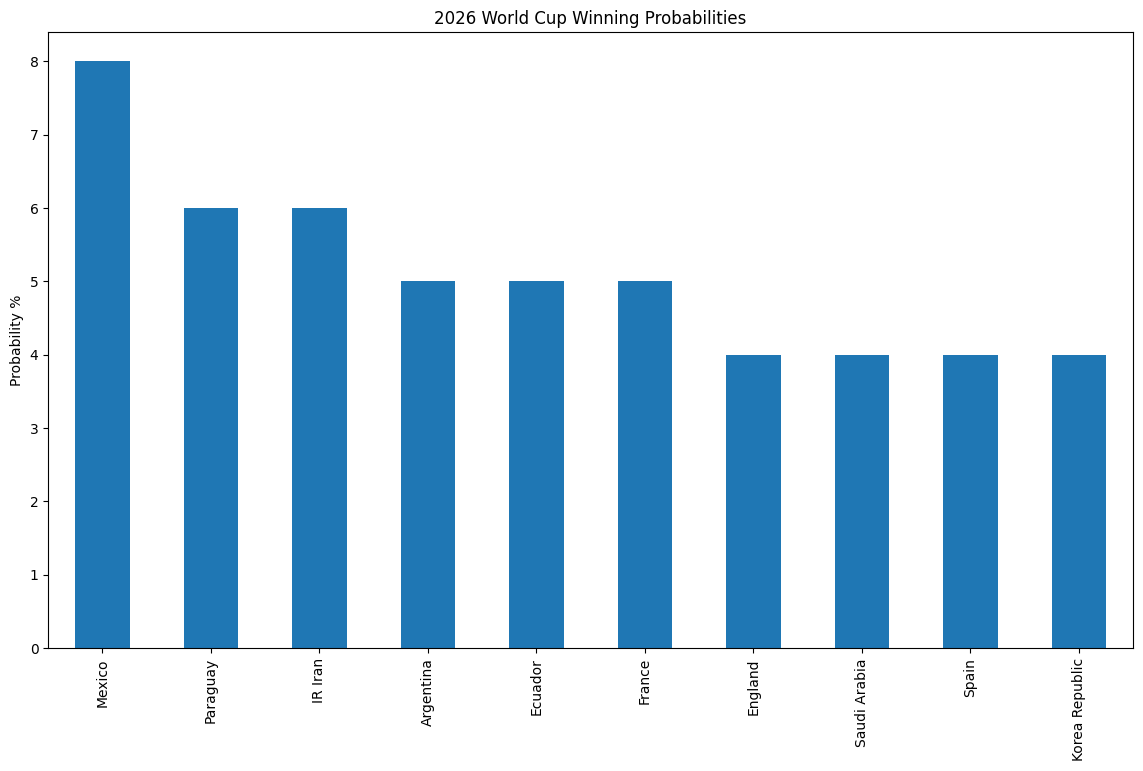

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

champion_probs.head(10).plot(
    kind='bar'
)

plt.title(
    "2026 World Cup Winning Probabilities"
)

plt.ylabel("Probability %")

plt.show()

array(['Mexico', 'Korea Republic', 'Canada', 'USA', 'Haiti', 'Australia',
       'Brazil', 'Qatar', "Côte d'Ivoire", 'Germany', 'Netherlands',
       'Albania/Poland/Sweden/Ukraine', 'Saudi Arabia', 'Spain',
       'IR Iran', 'Belgium', 'France', 'Bolivia/Iraq/Suriname',
       'Argentina', 'Austria', 'Ghana', 'England', 'Portugal',
       'Uzbekistan',
       'Czechia/Denmark/North Macedonia/Republic of Ireland',
       'Switzerland', 'Scotland', 'Kosovo/Romania/Slovakia/Türkiye',
       'Ecuador', 'Tunisia', 'Uruguay', 'New Zealand', 'Norway', 'Jordan',
       'Panama', 'Colombia', 'Morocco',
       'Bosnia and Herzegovina/Italy/Northern Ireland/Wales',
       'South Africa', 'Curaçao', 'Japan', 'Paraguay', 'Senegal', 'Egypt',
       'Cabo Verde', 'Croatia', 'Algeria',
       'Congo DR/Jamaica/New Caledonia', 'Group A runners-up',
       'Group E winners', 'Group F winners', 'Group C winners',
       'Group I winners', 'Group E runners up', 'Group A winners',
       'Group L winners'

array(['South Africa',
       'Czechia/Denmark/North Macedonia/Republic of Ireland',
       'Bosnia and Herzegovina/Italy/Northern Ireland/Wales', 'Paraguay',
       'Scotland', 'Kosovo/Romania/Slovakia/Türkiye', 'Morocco',
       'Switzerland', 'Ecuador', 'Curaçao', 'Japan', 'Tunisia', 'Uruguay',
       'Cabo Verde', 'New Zealand', 'Egypt', 'Senegal', 'Norway',
       'Algeria', 'Jordan', 'Panama', 'Croatia',
       'Congo DR/Jamaica/New Caledonia', 'Colombia', 'Qatar',
       'Korea Republic', 'Haiti', 'Australia', "Côte d'Ivoire",
       'Albania/Poland/Sweden/Ukraine', 'Saudi Arabia', 'IR Iran',
       'Bolivia/Iraq/Suriname', 'Austria', 'Ghana', 'Uzbekistan',
       'Brazil', 'Canada', 'Mexico', 'Germany', 'Netherlands', 'USA',
       'France', 'Belgium', 'Spain', 'England', 'Argentina', 'Portugal',
       'Group B runners-up', 'Group A/B/C/D/F third place',
       'Group C runners-up', 'Group F runners-up',
       'Group C/D/F/G/H third place', 'Group I runners-up',
       'Group